[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danieldidriksen/Bachelor_Project/blob/main/week_7_Fundas_CLASS.ipynb)

# Import

In [14]:
!git clone https://github.com/danieldidriksen/Bachelor_Project.git

from Bachelor_Project.Image_analysis_class_week13 import ImageAnalyzer as IA

Cloning into 'Bachelor_Project'...


# Part 1 Setup

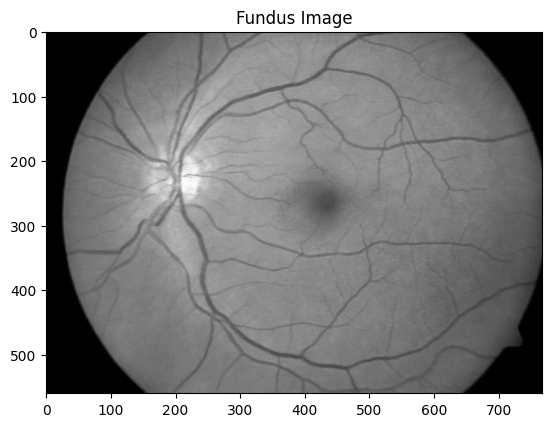

In [15]:
# Insert image here
imagefile = "Bachelor_Project/Images/Fundas_image.jpg"
img = IA.load_crop_grayscale(imagefile)[8:-8,:]
IA.plot_image(img, "Fundus Image")

# Part 2: Creating the Structure Tensor

## Computing gradients while smoothing of the pictures

In [16]:
S = IA.compute_structure_tensor(img, 1, 2)


# Part 3: Finding the dominant orientation

## Eigen Decomposition

In [17]:
evals, evecs = IA.eigendecomposition(S)

lam_small, lam_large, v_small, v_large  = IA.split_eigenpairs(evals, evecs)

theta = IA.orientation_from_eigenvectors(v_small)

vx, vy = IA.orientation_to_unit_vectors(theta)

## Plotting the Dominant Orientations

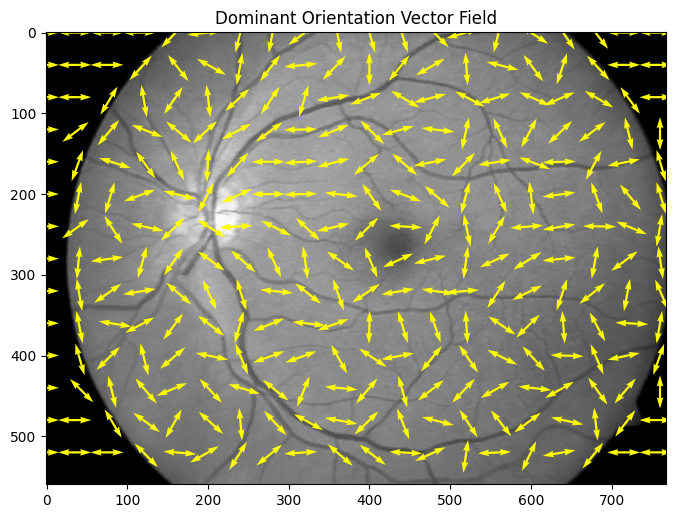

In [18]:
IA.plot_orientation_vectors(img, S, 40)

# Part 4: Histogram and Colour Overlay

## Overlaying on picture

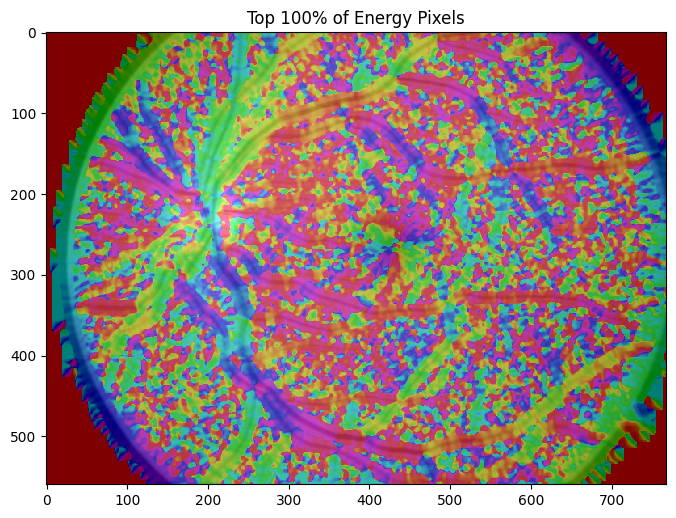

In [19]:
IA.plot_orientation_overlay(img, theta, opaqueness=0.50)

## Making histogram

In [20]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta)

## Plotting histogram

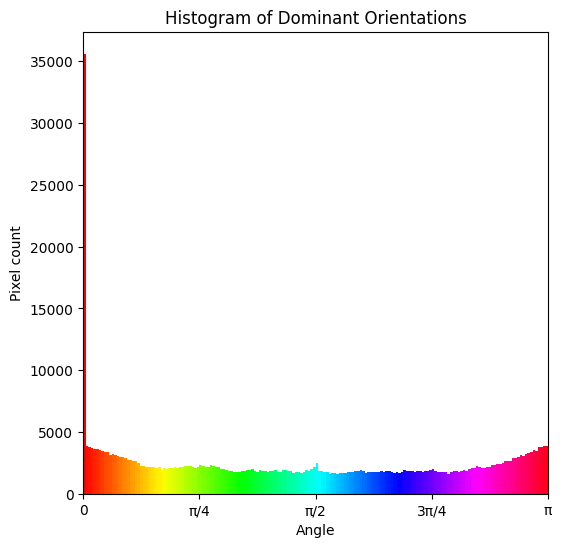

In [21]:
IA.plot_orientation_histogram(counts, bin_centers, bin_width, False)

## Making and plotting polar histogram

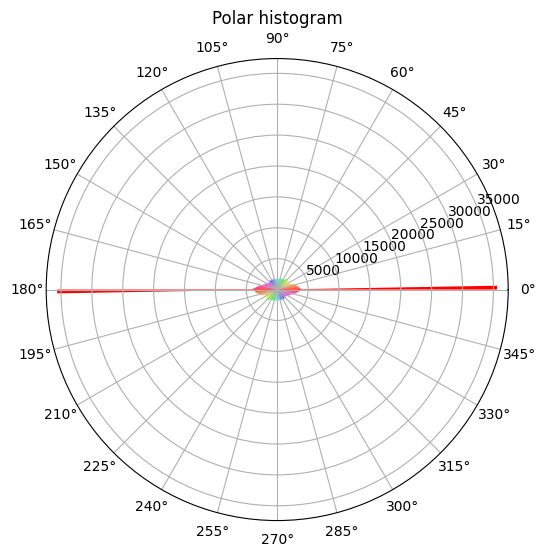

In [22]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = False)

# Part 5: Isotropy

## Applying Isotropy mask

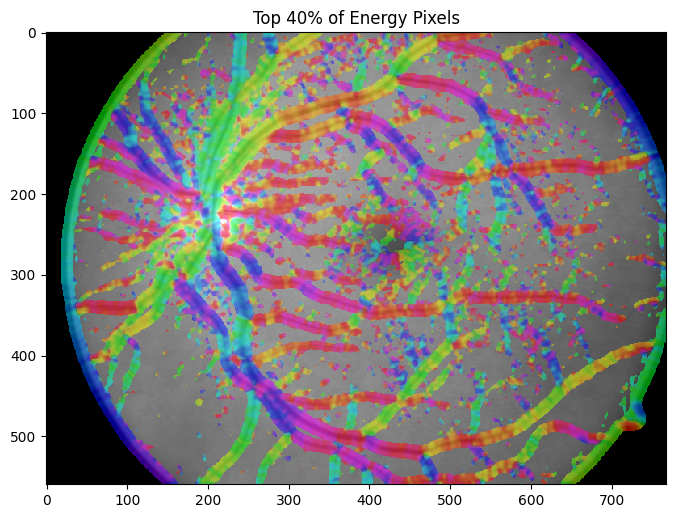

In [23]:
percent = 60
anisotropy_masked = IA.compute_anisotropy_masked(S, 50)
IA.plot_orientation_overlay(img, theta, anisotropy_masked, percent)

## Calculating and plotting weighted Histogram

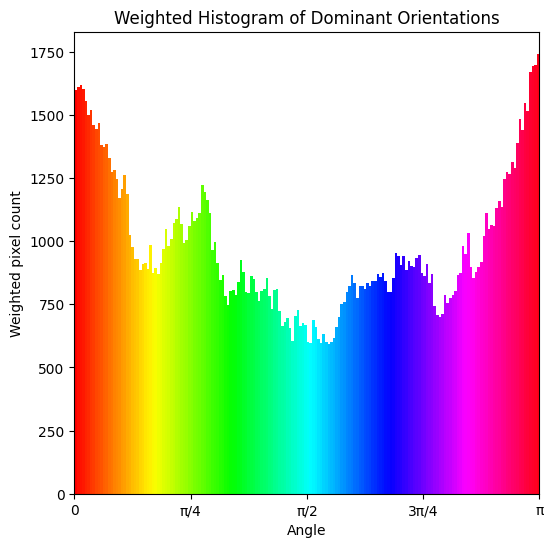

In [24]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta, anisotropy_masked)

IA.plot_orientation_histogram(counts, bin_centers, bin_width, weighted = True)

## Plotting weighted Polar Histogram

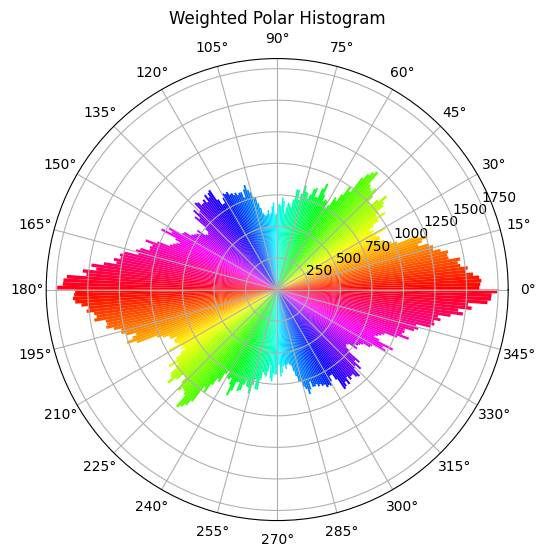

In [25]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = True)